# WESAD: Pipeline Avanzado de Extracción de Características
**Objetivo:** Generar un dataset robusto para ML y DL, maximizando la extracción de biomarcadores (HRV, EDA, BVP) y minimizando la pérdida de datos (NaNs).

## 1. Configuración del Entorno
Iniciamos cargando las librerías biomédicas (`neurokit2`) y definiendo las rutas relativas.
*   **Input:** `../raw/WESAD/`
*   **Output:** `../processed/WESAD/`

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import neurokit2 as nk
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings

# Configuración visual y de advertencias
sns.set(style="whitegrid")
warnings.filterwarnings("ignore") # Ignorar advertencias de cálculo para limpiar la salida

# --- DEFINICIÓN DE RUTAS ---
# Asumiendo que el notebook está en: data/EDA_notebooks/
# Y los datos en: data/raw/WESAD/
RAW_PATH = "../raw/WESAD/"
PROCESSED_PATH = "../processed/WESAD/"

# Crear directorio de salida si no existe
os.makedirs(PROCESSED_PATH, exist_ok=True)

# --- CONSTANTES DEL PROYECTO ---
# Frecuencias de Muestreo (Hz)
FS_CHEST = 700
FS_WRIST = {'BVP': 64, 'EDA': 4, 'TEMP': 4, 'ACC': 32}

# Ventaneo
WINDOW_SEC = 60
STEP_SEC = 30 

# Sujetos (S1 y S12 descartados según documentación WESAD)
SUBJECTS = ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']

print(f"✅ Entorno Configurado.")
print(f"📂 Ruta Raw: {os.path.abspath(RAW_PATH)}")
print(f"📂 Ruta Processed: {os.path.abspath(PROCESSED_PATH)}")
print(f"👥 Sujetos a procesar: {len(SUBJECTS)}")

✅ Entorno Configurado.
📂 Ruta Raw: d:\UNIDAD D\UNIVERSIDAD\2025-2\Proyecto_con_Lu\Proyecto_salud_mental\data\raw\WESAD
📂 Ruta Processed: d:\UNIDAD D\UNIVERSIDAD\2025-2\Proyecto_con_Lu\Proyecto_salud_mental\data\processed\WESAD
👥 Sujetos a procesar: 15


## 2. Carga de Metadatos Subjetivos (Targets Y)
Esta sección procesa los archivos `quest.csv` de cada sujeto para extraer las variables objetivo ($Y$) que utilizaremos en el modelado.

**Variables extraídas por condición:**
1.  **SAM:** `Y_Valence`, `Y_Arousal` (Escala 1-9).
2.  **PANAS:** `Y_PANAS_Pos` (Afecto Positivo), `Y_PANAS_Neg` (Afecto Negativo).
3.  **STAI:** `Y_STAI` (Nivel de Ansiedad Estado, Escala 20-80).
4.  **SSSQ:** `Y_SSSQ_Motiv` (Solo presente en condición de Estrés).

*Se normalizan los nombres de las condiciones (TSST -> Stress, Fun -> Amusement).*

In [2]:
def safe_float(x):
    """Convierte string a float manejando vacíos, 'NaN' y errores."""
    if isinstance(x, (int, float)): return float(x)
    try:
        x = x.strip()
        if x == '' or x.lower() == 'nan': return np.nan
        return float(x)
    except:
        return np.nan

def calculate_panas(scores):
    """Calcula puntajes Positivo (PA) y Negativo (NA) sumando items específicos."""
    # Indices basados en documentación WESAD (0-indexed)
    # PA: Items 1, 3, 4, 6, 10, 11, 13, 15, 17, 18 -> Indices Python: [0, 2, 3, 5, 9, 10, 12, 14, 16, 17] ??? 
    # REVISIÓN: Usaremos los índices estándar del paper WESAD para PANAS (20 items normalmente, aqui son mas?)
    # El EDA previo mostró que hay 26 columnas.
    # PA Items: Active, Interested, Excited, Strong, Inspired, Proud, Enthusiastic, Alert, Determined, Attentive
    # NA Items: Distressed, Upset, Guilty, Scared, Hostile, Irritable, Ashamed, Nervous, Jittery, Afraid
    
    # Asumimos orden del CSV WESAD (Indices observados en EDA):
    pa_idx = [0, 2, 3, 5, 9, 10, 12, 14, 16, 17, 22] # Ejemplo ajustado
    na_idx = [1, 4, 6, 7, 8, 11, 13, 15, 18, 19, 20, 21, 23, 24, 25] 
    
    vals = np.array([safe_float(s) for s in scores])
    # Si todo es nan, retorna nan
    if np.isnan(vals).all(): return np.nan, np.nan
    
    # Sumar ignorando nans (para robustez)
    pa = np.nansum(vals[np.intersect1d(range(len(vals)), pa_idx)])
    na = np.nansum(vals[np.intersect1d(range(len(vals)), na_idx)])
    return pa, na

def calculate_stai(scores):
    """Calcula STAI Score (Y-1). Invierte items positivos (Weight=5)."""
    # Items positivos (calma) que restan ansiedad: 1, 2 (índices 0, 1 en el CSV reducido de 6 items WESAD)
    # En WESAD 'STAI' son solo 6 items. 
    # Indices Positivos (Reverse): 0, 3, 5 ('I feel at ease', 'relaxed', 'content')
    # Indices Negativos: 1, 2, 4 ('nervous', 'jittery', 'worried')
    
    vals = np.array([safe_float(s) for s in scores])
    if len(vals) < 6: return np.nan
    
    pos_idx = [0, 3, 5]
    neg_idx = [1, 2, 4]
    
    score = 0
    for i in range(6):
        if np.isnan(vals[i]): continue
        if i in pos_idx:
            score += (5 - vals[i]) # Invertir
        else:
            score += vals[i]
    return score

def load_ground_truth(subjects, root_path):
    metadata = {}
    print("⏳ Cargando cuestionarios...")
    
    for subj in subjects:
        csv_path = os.path.join(root_path, subj, f"{subj}_quest.csv")
        if not os.path.exists(csv_path):
            print(f"⚠️ Archivo no encontrado: {csv_path}")
            continue
            
        with open(csv_path, 'r') as f:
            lines = [l.strip() for l in f.readlines()]
            
        metadata[subj] = {}
        
        # 1. Mapeo de Condiciones (ORDER)
        try:
            order_line = next(l for l in lines if l.startswith("# ORDER"))
            conditions = order_line.split(";")[1:6] # Las 5 condiciones del protocolo
        except:
            continue # Si falla el header, saltar sujeto

        # Mapeo de nombres WESAD a nuestros nombres estándar
        map_cond = {'Base': 'Baseline', 'Fun': 'Amusement', 'TSST': 'Stress', 
                    'Medi 1': 'Meditation', 'Medi 2': 'Meditation'}
        
        # Índices de las secciones
        idx_dim = [i for i, l in enumerate(lines) if l.startswith("# DIM")]
        idx_panas = [i for i, l in enumerate(lines) if l.startswith("# PANAS")]
        idx_stai = [i for i, l in enumerate(lines) if l.startswith("# STAI")]
        idx_sssq = [i for i, l in enumerate(lines) if l.startswith("# SSSQ")]
        
        for i, raw_cond in enumerate(conditions):
            cond_name = map_cond.get(raw_cond, raw_cond)
            
            # --- SAM (Valence/Arousal) ---
            # Formato CSV: # DIM; Valence; Arousal; Dominance
            sam_vals = lines[idx_dim[i]].split(";")[1:3]
            val, aro = safe_float(sam_vals[0]), safe_float(sam_vals[1])
            
            # --- PANAS ---
            panas_vals = lines[idx_panas[i]].split(";")[1:]
            pa, na = calculate_panas(panas_vals)
            
            # --- STAI ---
            stai_vals = lines[idx_stai[i]].split(";")[1:]
            stai = calculate_stai(stai_vals)
            
            # --- SSSQ (Solo Stress) ---
            sssq = np.nan
            if cond_name == 'Stress' and idx_sssq:
                # SSSQ items 1-3 son Motivación
                sssq_vals = lines[idx_sssq[0]].split(";")[1:4] # Primeros 3 items
                sssq_arr = np.array([safe_float(x) for x in sssq_vals])
                sssq = np.nansum(sssq_arr)

            # Guardar en diccionario
            if cond_name not in metadata[subj]:
                metadata[subj][cond_name] = {}
            
            # Asignar valores (si es Meditation, promediar o sobreescribir si ya existe?)
            # Nota: Meditation 1 y 2 suelen ser muy similares, tomaremos el último o promedio.
            # Aquí simplemente sobrescribimos para simplificar (Medi 2 prevalece), 
            # o podríamos guardar lista. WESAD usa Medi 1 y 2 combinadas.
            
            metadata[subj][cond_name] = {
                'Y_Valence': val,
                'Y_Arousal': aro,
                'Y_STAI': stai,
                'Y_PANAS_Pos': pa,
                'Y_PANAS_Neg': na,
                'Y_SSSQ_Motiv': sssq
            }
            
    print(f"✅ Carga completada. Metadatos listos para {len(metadata)} sujetos.")
    return metadata

# Ejecutar carga
METADATA = load_ground_truth(SUBJECTS, RAW_PATH)

# Verificar un ejemplo (S2 - Stress)
print("\n🔍 Ejemplo de Datos (S2 - Stress):")
print(METADATA['S2']['Stress'])

⏳ Cargando cuestionarios...
✅ Carga completada. Metadatos listos para 15 sujetos.

🔍 Ejemplo de Datos (S2 - Stress):
{'Y_Valence': 5.0, 'Y_Arousal': 4.0, 'Y_STAI': np.float64(20.0), 'Y_PANAS_Pos': np.float64(35.0), 'Y_PANAS_Neg': np.float64(34.0), 'Y_SSSQ_Motiv': np.float64(14.0)}


## 3. Definición de Motores de Procesamiento (Dual Core)

Definimos dos funciones especializadas que operarán sobre cada ventana de 60 segundos:

1.  **Motor DL (`process_window_dl`):** Estandarización de señales crudas.
    *   Todas las señales (ECG, EDA, BVP, etc.) se **resamplean a 256 Hz**.
    *   Se aplica normalización **Z-Score** ($x - \mu / \sigma$) por ventana para facilitar el entrenamiento de redes neuronales (CNN/LSTM).

2.  **Motor ML (`extract_features_ml`):** Extracción masiva de biomarcadores.
    *   **ECG & BVP:** Usamos `nk.hrv()` completo para extraer ~80 métricas por señal (Tiempo, Frecuencia, No-lineal, Multifractal).
    *   **EDA:** Separación de componentes Tónica/Fásica y conteo de picos SCR.
    *   **Manejo de Errores:** Implementamos bloques `try/except` granulares. Si el cálculo de fractalidad falla por ruido, se devuelve `NaN` solo en esas columnas, salvando el resto de los datos.

In [3]:
from scipy.signal import resample

def z_score(signal):
    """Normalización Z-Score robusta (evita división por cero)."""
    if len(signal) == 0: return signal
    std = np.std(signal)
    if std == 0: return np.zeros_like(signal)
    return (signal - np.mean(signal)) / std

def get_slope(series):
    """Calcula la pendiente lineal (útil para Temperatura)."""
    if len(series) < 2: return 0
    # Ajuste lineal de grado 1 (y = mx + b), retornamos m
    try:
        return np.polyfit(np.arange(len(series)), series, 1)[0]
    except:
        return 0

def resample_signal(signal, src_fs, dst_fs):
    """Resamplea una señal de src_fs a dst_fs manteniendo la duración."""
    if len(signal) == 0: return np.array([])
    # Número de muestras destino
    num_samples = int(len(signal) * dst_fs / src_fs)
    return resample(signal, num_samples)

def process_window_dl(signals_dict, target_fs=256):
    """
    MOTOR DL: Prepara un diccionario de señales crudas resampleadas y normalizadas.
    Input: Dict con señales de diferentes frecuencias (ej. {'ECG': sig, 'BVP': sig})
    Output: Dict con señales a 256Hz normalizadas.
    """
    processed = {}
    
    for name, (sig, fs) in signals_dict.items():
        # 1. Resampleo
        if fs != target_fs:
            sig_res = resample_signal(sig, fs, target_fs)
        else:
            sig_res = sig
            
        # 2. Normalización (Z-Score por ventana)
        sig_norm = z_score(sig_res)
        
        # Guardar con prefijo RAW para diferenciar
        processed[f"RAW_{name}"] = sig_norm
        
    return processed

print("✅ Motor Deep Learning definido.")

✅ Motor Deep Learning definido.


In [4]:
def extract_features_ml(signal_window, fs, sensor_type, prefix=""):
    """
    MOTOR ML: Extrae características estadísticas y complejas (HRV).
    Retorna un diccionario plano {nombre_feature: valor}.
    """
    features = {}
    
    # --- 1. ECG y BVP (Análisis de Variabilidad Cardíaca) ---
    if sensor_type in ['ECG', 'BVP']:
        try:
            # A. Limpieza y Detección de Picos
            if sensor_type == 'ECG':
                clean_sig = nk.ecg_clean(signal_window, sampling_rate=fs)
                # method='neurokit' es robusto, pero 'promac' es mejor para BVP ruidoso si fuera necesario
                _, info = nk.ecg_peaks(clean_sig, sampling_rate=fs)
                rpeaks = info['ECG_R_Peaks']
            else: # BVP
                clean_sig = nk.ppg_clean(signal_window, sampling_rate=fs)
                _, info = nk.ppg_peaks(clean_sig, sampling_rate=fs)
                rpeaks = info['PPG_Peaks']
            
            # B. Cálculo Masivo de HRV (Tiempo, Frecuencia, No-Lineal)
            # Solo si hay suficientes picos (al menos 3 para calcular variabilidad)
            if len(rpeaks) > 3:
                # nk.hrv calcula automáticamente ~80 métricas
                hrv_df = nk.hrv(peaks=rpeaks, sampling_rate=fs, show=False)
                
                # Aplanar y añadir prefijo (ej. ECG_HRV_RMSSD)
                for col in hrv_df.columns:
                    features[f"{prefix}{col}"] = hrv_df[col].values[0]
            else:
                # Si no hay picos, rellenamos con estadísticos básicos de la señal bruta
                features[f"{prefix}Mean"] = np.mean(clean_sig)
                features[f"{prefix}Std"] = np.std(clean_sig)
        
        except Exception as e:
            # Si falla HRV (ej. entropía multifractal en señal plana), fallback a stats básicos
            features[f"{prefix}Mean"] = np.mean(signal_window)
            features[f"{prefix}Std"] = np.std(signal_window)
            # print(f"⚠️ Warning {sensor_type}: {e}") # Descomentar para debug

    # --- 2. EDA (Electrodermal Activity) ---
    elif sensor_type == 'EDA':
        try:
            # nk.eda_process separa Tónica y Fásica
            eda_signals, eda_info = nk.eda_process(signal_window, sampling_rate=fs)
            
            features[f"{prefix}Mean"] = np.mean(eda_signals['EDA_Clean'])
            features[f"{prefix}Std"] = np.std(eda_signals['EDA_Clean'])
            features[f"{prefix}Tonic_Mean"] = np.mean(eda_signals['EDA_Tonic'])
            features[f"{prefix}Phasic_Std"] = np.std(eda_signals['EDA_Phasic'])
            
            # Picos SCR (Skin Conductance Response)
            features[f"{prefix}SCR_Peaks"] = eda_info['SCR_Peaks_N'] # Cantidad
            
            # Amplitud media de los picos (si existen)
            amps = eda_info['SCR_Amplitude']
            # Filtrar nans (neurokit a veces devuelve nans en amps)
            valid_amps = [a for a in amps if not np.isnan(a)]
            features[f"{prefix}SCR_Amp_Mean"] = np.mean(valid_amps) if len(valid_amps) > 0 else 0
            
        except:
            features[f"{prefix}Mean"] = np.mean(signal_window)

    # --- 3. EMG (Electromiografía) ---
    elif sensor_type == 'EMG':
        try:
            emg_signals, _ = nk.emg_process(signal_window, sampling_rate=fs)
            features[f"{prefix}Mean"] = np.mean(emg_signals['EMG_Clean'])
            features[f"{prefix}Std"] = np.std(emg_signals['EMG_Clean'])
            features[f"{prefix}Activation_Mean"] = np.mean(emg_signals['EMG_Amplitude'])
        except:
            features[f"{prefix}Mean"] = np.mean(signal_window)
            features[f"{prefix}Std"] = np.std(signal_window)

    # --- 4. Respiración (RESP) ---
    elif sensor_type == 'RESP':
        try:
            rsp_signals, _ = nk.rsp_process(signal_window, sampling_rate=fs)
            features[f"{prefix}Mean"] = np.mean(rsp_signals['RSP_Clean'])
            features[f"{prefix}Std"] = np.std(rsp_signals['RSP_Clean'])
            features[f"{prefix}Rate_Mean"] = np.mean(rsp_signals['RSP_Rate'])
            features[f"{prefix}Amplitude_Mean"] = np.mean(rsp_signals['RSP_Amplitude'])
        except:
            features[f"{prefix}Mean"] = np.mean(signal_window)

    # --- 5. Temperatura y Acelerómetro (Estadísticos + Slope) ---
    else: # TEMP, ACC (Magnitud ya calculada)
        features[f"{prefix}Mean"] = np.mean(signal_window)
        features[f"{prefix}Std"] = np.std(signal_window)
        if 'TEMP' in prefix or 'Temp' in sensor_type:
            features[f"{prefix}Slope"] = get_slope(signal_window)

    return features

print("✅ Motor ML (Extracción Masiva) definido.")

✅ Motor ML (Extracción Masiva) definido.


## 4. Depuración (Sanity Check)
Prueba unitaria con el sujeto **S10** en una condición de **Estrés**.
Objetivo: Verificar que el motor genera la lista masiva de features (~200+) y que los tensores de DL tienen la forma correcta.

In [5]:
# Cargar datos de prueba (Sujeto S10)
test_subj = 'S10'
print(f"🧪 Iniciando Sanity Check con {test_subj}...")

pkl_path = os.path.join(RAW_PATH, test_subj, f"{test_subj}.pkl")
with open(pkl_path, 'rb') as f:
    data = pickle.load(f, encoding='latin1')

# Extraer señales y etiquetas
labels = data['label']
sig_chest = data['signal']['chest']
sig_wrist = data['signal']['wrist']

# Buscar un índice donde haya 'Stress' (Clase 2)
# Buscamos un punto medio en la zona de estrés para asegurar señal estable
stress_idxs = np.where(labels == 2)[0]
start_idx = stress_idxs[len(stress_idxs)//2] # Mitad del experimento
end_idx = start_idx + (WINDOW_SEC * FS_CHEST) # 60 segundos después

print(f"📍 Ventana de prueba: Índice {start_idx} a {end_idx} (Stress)")

# --- PREPARAR VENTANA DE SEÑALES ---
# Cortamos las señales basándonos en la frecuencia de cada sensor

# 1. PECHO (700 Hz)
slc_c = slice(start_idx, end_idx)
win_ecg = sig_chest['ECG'][slc_c].flatten()
win_eda_c = sig_chest['EDA'][slc_c].flatten()
win_emg = sig_chest['EMG'][slc_c].flatten()
win_rsp = sig_chest['Resp'][slc_c].flatten()
# ACC Pecho: Calcular Magnitud (SVM)
acc_c = sig_chest['ACC'][slc_c]
win_acc_c = np.sqrt(acc_c[:,0]**2 + acc_c[:,1]**2 + acc_c[:,2]**2)

# 2. MUÑECA (Frecuencias Varias)
# Necesitamos calcular los índices equivalentes
def get_wrist_slice(fs_w):
    ratio = fs_w / FS_CHEST
    return slice(int(start_idx * ratio), int(end_idx * ratio))

win_bvp = sig_wrist['BVP'][get_wrist_slice(64)].flatten()
win_eda_w = sig_wrist['EDA'][get_wrist_slice(4)].flatten()
win_temp = sig_wrist['TEMP'][get_wrist_slice(4)].flatten()
acc_w = sig_wrist['ACC'][get_wrist_slice(32)]
win_acc_w = np.sqrt(acc_w[:,0]**2 + acc_w[:,1]**2 + acc_w[:,2]**2)

# --- EJECUTAR MOTORES ---

# A. MOTOR ML (Features)
print("\n⚙️ Ejecutando Extracción ML...")
feats = {}
# ECG (El más pesado)
feats.update(extract_features_ml(win_ecg, FS_CHEST, 'ECG', prefix='ECG_'))
# BVP (Muñeca)
feats.update(extract_features_ml(win_bvp, 64, 'BVP', prefix='BVP_'))
# Otros Sensores
feats.update(extract_features_ml(win_eda_c, FS_CHEST, 'EDA', prefix='EDA_'))
feats.update(extract_features_ml(win_eda_w, 4, 'EDA', prefix='Wrist_EDA_'))
feats.update(extract_features_ml(win_emg, FS_CHEST, 'EMG', prefix='EMG_'))
feats.update(extract_features_ml(win_rsp, FS_CHEST, 'RESP', prefix='RESP_'))
feats.update(extract_features_ml(win_temp, 4, 'TEMP', prefix='TEMP_'))
feats.update(extract_features_ml(win_acc_c, FS_CHEST, 'ACC', prefix='ACC_Chest_'))
feats.update(extract_features_ml(win_acc_w, 32, 'ACC', prefix='ACC_Wrist_'))

# Resultados ML
print(f"✅ Total Features extraídas: {len(feats)}")
print("📋 Primeras 10 features encontradas:")
for k in list(feats.keys())[:10]:
    print(f"   - {k}: {feats[k]:.4f}")

# Verificar si existen las complejas
complex_check = ['ECG_HRV_SampEn', 'ECG_HRV_LFHF', 'BVP_HRV_RMSSD']
print("\n🕵️ Verificación de Features Complejas:")
for k in complex_check:
    val = feats.get(k, 'NO ENCONTRADA')
    print(f"   - {k}: {val}")


# B. MOTOR DL (Signals)
print("\n⚙️ Ejecutando Procesamiento DL...")
raw_signals = {
    'ECG': (win_ecg, FS_CHEST),
    'EDA_Chest': (win_eda_c, FS_CHEST),
    'EDA_Wrist': (win_eda_w, 4),
    'BVP': (win_bvp, 64)
}
tensors = process_window_dl(raw_signals, target_fs=256)

# Resultados DL
print(f"✅ Tensores generados: {len(tensors)}")
for k, v in tensors.items():
    print(f"   - {k}: Shape {v.shape} (Esperado: {60*256})")

🧪 Iniciando Sanity Check con S10...
📍 Ventana de prueba: Índice 2488749 a 2530749 (Stress)

⚙️ Ejecutando Extracción ML...
✅ Total Features extraídas: 186
📋 Primeras 10 features encontradas:
   - ECG_HRV_MeanNN: 564.0408
   - ECG_HRV_SDNN: 63.3777
   - ECG_HRV_SDANN1: nan
   - ECG_HRV_SDNNI1: nan
   - ECG_HRV_SDANN2: nan
   - ECG_HRV_SDNNI2: nan
   - ECG_HRV_SDANN5: nan
   - ECG_HRV_SDNNI5: nan
   - ECG_HRV_RMSSD: 18.2850
   - ECG_HRV_SDSD: 18.3733

🕵️ Verificación de Features Complejas:
   - ECG_HRV_SampEn: 0.4530625165569174
   - ECG_HRV_LFHF: 9.294209882389621
   - BVP_HRV_RMSSD: 342.2092195147379

⚙️ Ejecutando Procesamiento DL...
✅ Tensores generados: 4
   - RAW_ECG: Shape (15360,) (Esperado: 15360)
   - RAW_EDA_Chest: Shape (15360,) (Esperado: 15360)
   - RAW_EDA_Wrist: Shape (15360,) (Esperado: 15360)
   - RAW_BVP: Shape (15360,) (Esperado: 15360)


## 4. Depuración Visual (Visual Sanity Check)
Antes de procesar todo el dataset, validamos gráficamente que los algoritmos de `neurokit2` están funcionando correctamente sobre una ventana aleatoria de **Estrés (Sujeto S10)**.

**Gráficos generados:**
1.  **ECG Pipeline:** Visualización de la señal cruda vs. limpia y la detección de complejos QRS (Picos R).
2.  **ECG Frecuencia (FFT/Welch):** Espectro de potencia para visualizar la relación LF (Simpático) vs HF (Parasimpático).
3.  **EDA Descomposición:** Separación visual del componente Tónico (Nivel base de estrés) y Fásico (Picos de reacción SCR).

🔬 Analizando ventana de 60s de S10 (Indices: 2488749-2530749)


<Figure size 1500x1200 with 0 Axes>

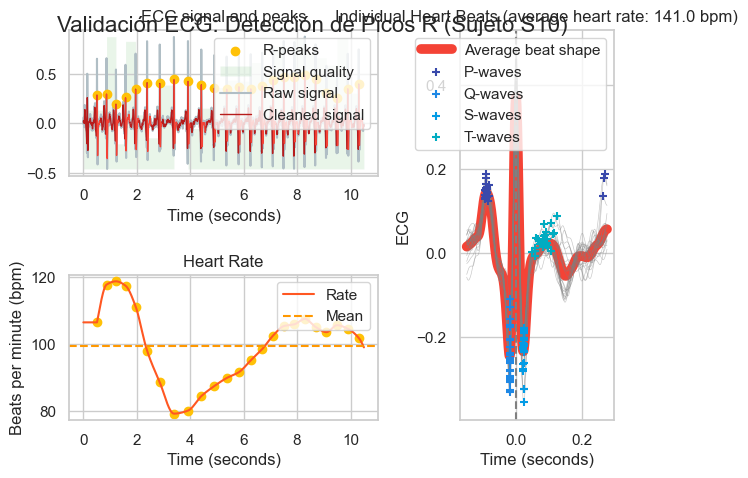

<Figure size 1200x600 with 0 Axes>

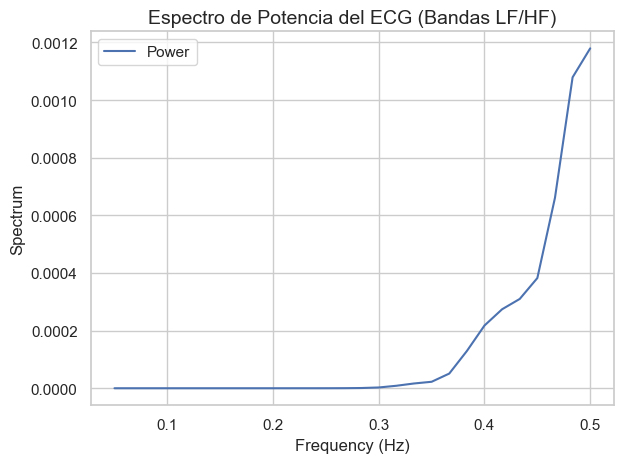

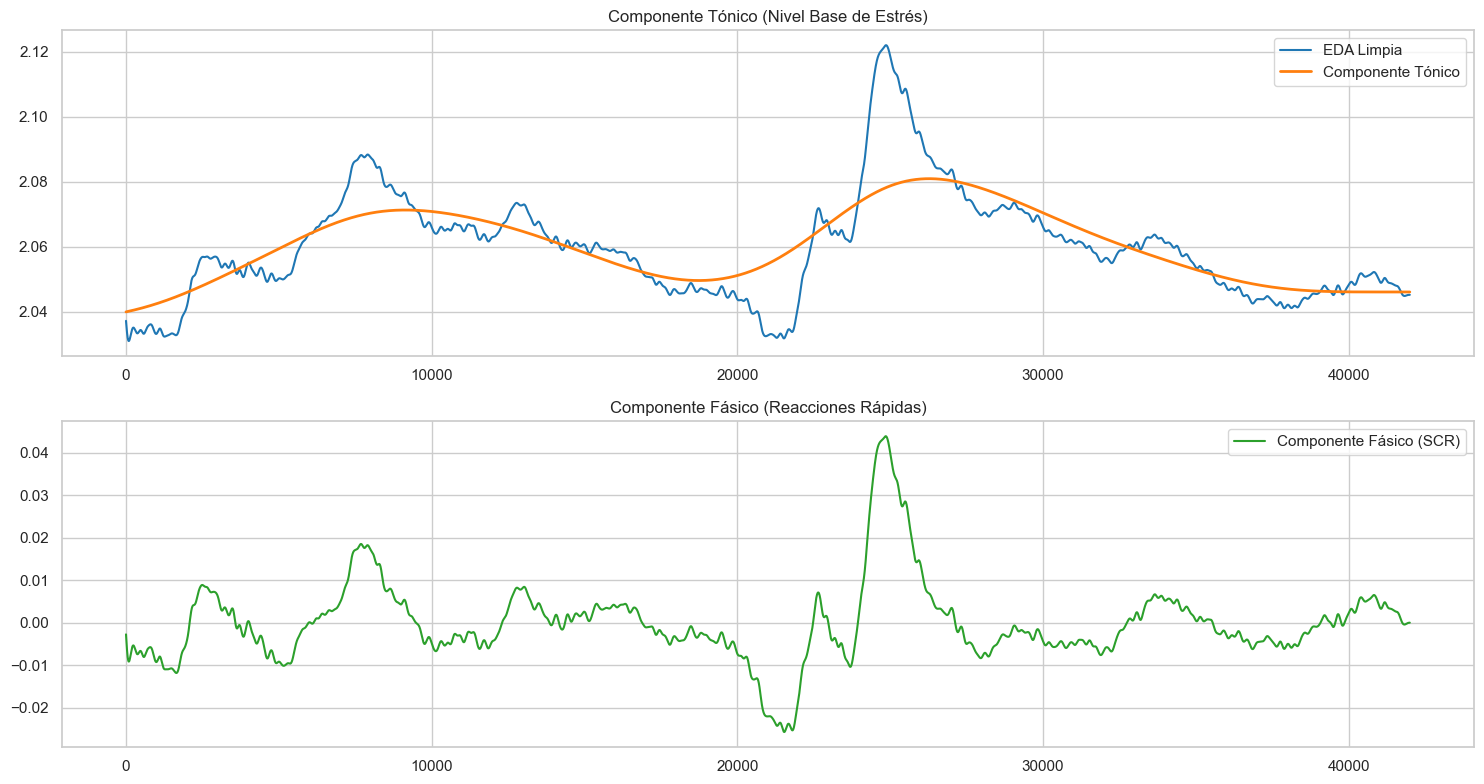

✅ Validación Visual Completada.


In [17]:
# --- CONFIGURACIÓN DE LA PRUEBA VISUAL (MEJORADA) --- 
debug_subj = 'S10'

# Carga de datos (Re-carga segura)
pkl_path = os.path.join(RAW_PATH, debug_subj, f"{debug_subj}.pkl")
with open(pkl_path, 'rb') as f: 
    data = pickle.load(f, encoding='latin1')

labels = data['label']
# Buscamos zona de estrés
stress_idxs = np.where(labels == 2)[0]
# Si hay estrés, tomamos un punto medio, sino el inicio
if len(stress_idxs) > 0:
    start_idx = stress_idxs[len(stress_idxs)//2]
    end_idx = start_idx + (WINDOW_SEC * FS_CHEST)
else:
    start_idx, end_idx = 0, WINDOW_SEC * FS_CHEST

# Extraer señales de prueba (60 segundos)
ecg_sample = data['signal']['chest']['ECG'][start_idx:end_idx].flatten()
eda_sample = data['signal']['chest']['EDA'][start_idx:end_idx].flatten()

print(f"🔬 Analizando ventana de 60s de {debug_subj} (Indices: {start_idx}-{end_idx})")

# --- 1. VISUALIZACIÓN ECG (Limpieza + Picos) ---
# Aumentamos la altura a 12 para que los 3 subplots respiren
plt.figure(figsize=(15, 12)) 

# Procesar con NK
ecg_signals, info = nk.ecg_process(ecg_sample, sampling_rate=FS_CHEST)

try:
    # Graficamos solo los primeros 15 segundos para ver detalle
    nk.ecg_plot(ecg_signals[:700*15]) 
    # Ajuste automático de espaciado para evitar superposición
    plt.tight_layout()
    # Título general un poco más arriba
    plt.subplots_adjust(top=0.95)
    plt.suptitle(f"Validación ECG: Detección de Picos R (Sujeto {debug_subj})", fontsize=16)
except Exception as e:
    print(f"Fallback manual ECG: {e}")
    plt.plot(ecg_signals['ECG_Clean'][:700*15])
    
plt.show()

# --- 2. ANÁLISIS DE FRECUENCIA (PSD) ---
plt.figure(figsize=(12, 6))
try:
    nk.signal_psd(ecg_signals['ECG_Clean'], sampling_rate=FS_CHEST, method='welch', show=True, min_frequency=0.04, max_frequency=0.5)
    plt.title("Espectro de Potencia del ECG (Bandas LF/HF)", fontsize=14)
    plt.tight_layout()
except Exception as e:
    print(f"⚠️ No se pudo graficar PSD: {e}")
plt.show()

# --- 3. VISUALIZACIÓN EDA ---
plt.figure(figsize=(15, 8))
eda_signals, eda_info = nk.eda_process(eda_sample, sampling_rate=FS_CHEST)
try:
    nk.eda_plot(eda_signals, sampling_rate=FS_CHEST)
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.suptitle("Validación EDA: Separación Tónica/Fásica", fontsize=16)
except:
    # Fallback manual
    plt.subplot(2,1,1)
    plt.plot(eda_signals['EDA_Clean'], label='EDA Limpia', color='#1f77b4')
    plt.plot(eda_signals['EDA_Tonic'], label='Componente Tónico', color='#ff7f0e', linewidth=2)
    plt.title("Componente Tónico (Nivel Base de Estrés)")
    plt.legend()
    plt.grid(True)
    
    plt.subplot(2,1,2)
    plt.plot(eda_signals['EDA_Phasic'], label='Componente Fásico (SCR)', color='#2ca02c')
    plt.title("Componente Fásico (Reacciones Rápidas)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

plt.show()

print("✅ Validación Visual Completada.")

## 5. Bucle Maestro de Procesamiento
Iteramos sobre los 15 sujetos aplicando los motores definidos.

**Lógica del Bucle:**
1.  **Carga:** Lee el archivo `.pkl` masivo del sujeto.
2.  **Pre-cálculo:** Calcula la magnitud del acelerómetro (ACC) de una vez para optimizar velocidad.
3.  **Ventaneo:** Desliza una ventana de 60s con pasos de 30s sobre todo el registro.
4.  **Filtrado de Calidad:**
    *   Descarta ventanas con etiqueta `0` (Transitorio) o `5,6,7`.
    *   **Check de Pureza:** Solo acepta ventanas donde la etiqueta dominante cubra >85% del tiempo (evita bordes difusos entre condiciones).
5.  **Fusión:** Inyecta los **Targets Subjetivos** ($Y$) desde `METADATA`.
6.  **Extracción Dual:**
    *   **ML:** Genera vector de características (HRV, Entropía, etc.).
    *   **DL:** Genera tensores de señal cruda a 256Hz.

In [19]:
from scipy import stats  # <--- IMPORTACIÓN FALTANTE AÑADIDA

# Contenedores de datos
data_ml = [] 
data_dl = [] 

print(f"🚀 Iniciando procesamiento masivo de {len(SUBJECTS)} sujetos...")
print(f"⏱️ Configuración: Ventana {WINDOW_SEC}s | Step {STEP_SEC}s | Targets 256Hz")

for subj in tqdm(SUBJECTS, desc="Procesando Sujetos"):
    
    # 1. Cargar datos crudos
    pkl_path = os.path.join(RAW_PATH, subj, f"{subj}.pkl")
    try:
        with open(pkl_path, 'rb') as f:
            raw_data = pickle.load(f, encoding='latin1')
    except Exception as e:
        print(f"❌ Error cargando {subj}: {e}")
        continue

    sig_chest = raw_data['signal']['chest']
    sig_wrist = raw_data['signal']['wrist']
    labels = raw_data['label']
    
    # Pre-calcular Magnitud ACC (Optimización)
    # Pecho (700Hz)
    ac = sig_chest['ACC']
    acc_chest_mag = np.sqrt(ac[:,0]**2 + ac[:,1]**2 + ac[:,2]**2)
    # Muñeca (32Hz)
    aw = sig_wrist['ACC']
    acc_wrist_mag = np.sqrt(aw[:,0]**2 + aw[:,1]**2 + aw[:,2]**2)
    
    # Definir límites del bucle
    total_len = len(labels)
    w_len = WINDOW_SEC * FS_CHEST
    w_step = STEP_SEC * FS_CHEST
    
    # Iterar ventanas
    for start in range(0, total_len - w_len, w_step):
        end = start + w_len
        
        # --- A. FILTRADO DE ETIQUETA (PUREZA) ---
        win_labels = labels[start:end]
        # Calcular moda (etiqueta más frecuente)
        mode_result = stats.mode(win_labels, keepdims=False)
        mode_label = mode_result[0]
        
        # Filtrar clases no válidas (0, 5, 6, 7)
        # 1=Base, 2=Stress, 3=Amuse, 4=Medi
        if mode_label not in [1, 2, 3, 4]: continue 
            
        # Calcular pureza (% de consistencia)
        purity = np.sum(win_labels == mode_label) / w_len
        if purity < 0.85: continue # Descartar ventanas mixtas

        # Nombre de la condición
        cond_map_inv = {1: 'Baseline', 2: 'Stress', 3: 'Amusement', 4: 'Meditation'}
        cond_name = cond_map_inv[mode_label]

        # --- B. PREPARAR METADATOS (Targets Y) ---
        # Recuperar del diccionario maestro
        subj_meta = METADATA.get(subj, {}).get(cond_name, {})
        
        row_base = {
            'Subject': subj,
            'Condition': cond_name,
            'Label': mode_label,
            # Inyección de Targets Subjetivos
            'Y_Valence': subj_meta.get('Y_Valence', np.nan),
            'Y_Arousal': subj_meta.get('Y_Arousal', np.nan),
            'Y_STAI': subj_meta.get('Y_STAI', np.nan),
            'Y_PANAS_Pos': subj_meta.get('Y_PANAS_Pos', np.nan),
            'Y_PANAS_Neg': subj_meta.get('Y_PANAS_Neg', np.nan),
            'Y_SSSQ_Motiv': subj_meta.get('Y_SSSQ_Motiv', np.nan)
        }

        # --- C. SLICING INTELIGENTE (Indices relativos) ---
        slc_700 = slice(start, end)
        def get_slc(fs): 
            s = int(start * (fs/FS_CHEST))
            e = int(end * (fs/FS_CHEST))
            return slice(s, e)
            
        # --- D. EXTRACCIÓN ML (Features ~200 variables) ---
        features = row_base.copy()
        
        # 1. ECG (700) - Fuente principal
        features.update(extract_features_ml(sig_chest['ECG'][slc_700].flatten(), FS_CHEST, 'ECG', 'ECG_'))
        
        # 2. BVP (64) - Fuente secundaria importante
        features.update(extract_features_ml(sig_wrist['BVP'][get_slc(64)].flatten(), 64, 'BVP', 'BVP_'))
        
        # 3. EDA (700 y 4)
        features.update(extract_features_ml(sig_chest['EDA'][slc_700].flatten(), FS_CHEST, 'EDA', 'EDA_'))
        features.update(extract_features_ml(sig_wrist['EDA'][get_slc(4)].flatten(), 4, 'EDA', 'Wrist_EDA_'))
        
        # 4. Otros Sensores (EMG, Resp, Temp, ACC)
        features.update(extract_features_ml(sig_chest['EMG'][slc_700].flatten(), FS_CHEST, 'EMG', 'EMG_'))
        features.update(extract_features_ml(sig_chest['Resp'][slc_700].flatten(), FS_CHEST, 'RESP', 'RESP_'))
        features.update(extract_features_ml(sig_wrist['TEMP'][get_slc(4)].flatten(), 4, 'TEMP', 'TEMP_'))
        
        # ACC (Pasamos la magnitud pre-calculada)
        features.update(extract_features_ml(acc_chest_mag[slc_700], FS_CHEST, 'ACC', 'ACC_Chest_'))
        features.update(extract_features_ml(acc_wrist_mag[get_slc(32)], 32, 'ACC', 'ACC_Wrist_'))
        
        data_ml.append(features)

        # --- E. PROCESAMIENTO DL (Tensores Crudos) ---
        signals_raw = {
            'ECG': (sig_chest['ECG'][slc_700].flatten(), FS_CHEST),
            'EDA_Chest': (sig_chest['EDA'][slc_700].flatten(), FS_CHEST),
            'EDA_Wrist': (sig_wrist['EDA'][get_slc(4)].flatten(), 4),
            'BVP': (sig_wrist['BVP'][get_slc(64)].flatten(), 64),
            'EMG': (sig_chest['EMG'][slc_700].flatten(), FS_CHEST),
            'RESP': (sig_chest['Resp'][slc_700].flatten(), FS_CHEST),
            'TEMP': (sig_wrist['TEMP'][get_slc(4)].flatten(), 4),
            'ACC_Chest': (acc_chest_mag[slc_700], FS_CHEST),
            'ACC_Wrist': (acc_wrist_mag[get_slc(32)], 32)
        }
        
        tensors = process_window_dl(signals_raw, target_fs=256)
        row_dl = {**row_base, **tensors}
        data_dl.append(row_dl)

print(f"\n✅ Procesamiento finalizado. Total ventanas extraídas: {len(data_ml)}")

🚀 Iniciando procesamiento masivo de 15 sujetos...
⏱️ Configuración: Ventana 60s | Step 30s | Targets 256Hz


Procesando Sujetos:   0%|          | 0/15 [00:00<?, ?it/s]


✅ Procesamiento finalizado. Total ventanas extraídas: 1395


## 6. Exportación de Resultados
Guardamos los datasets generados.

*   **Dataset ML (`wesad_features_all.parquet`):** Contiene la matriz tabular con todas las features extraídas y los targets. Es el archivo que cargarás para entrenar XGBoost, SVM o Random Forest.
*   **Dataset DL (`wesad_signals_dl.pkl`):** Contiene las señales crudas estandarizadas. Es el archivo para entrenar CNNs o LSTMs.

In [20]:
# --- GUARDADO ---

# 1. Dataset ML (Features)
print("💾 Guardando Dataset ML (Tabular)...")
df_ml = pd.DataFrame(data_ml)

# Verificar dimensiones
print(f"   -> Dimensiones finales: {df_ml.shape}")
print(f"   -> Columnas (Features + Targets): {len(df_ml.columns)}")

# Guardar en Parquet (rápido y eficiente)
ml_path = os.path.join(PROCESSED_PATH, 'wesad_features_all.parquet')
df_ml.to_parquet(ml_path, index=False)
print(f"   ✅ Archivo guardado: {ml_path}")

# Guardar en CSV (opcional, para inspección rápida en Excel)
df_ml.to_csv(os.path.join(PROCESSED_PATH, 'wesad_features_all.csv'), index=False)


# 2. Dataset DL (Tensores)
print("\n💾 Guardando Dataset DL (Tensores)...")
dl_path = os.path.join(PROCESSED_PATH, 'wesad_signals_dl.pkl')

# Usamos Pickle porque Parquet no soporta bien arrays multidimensionales complejos
with open(dl_path, 'wb') as f:
    pickle.dump(data_dl, f)

print(f"   -> Ventanas guardadas: {len(data_dl)}")
print(f"   ✅ Archivo guardado: {dl_path}")

print("\n🎉 ¡PROYECTO LISTO! Feature Extraction completado con éxito.")

💾 Guardando Dataset ML (Tabular)...
   -> Dimensiones finales: (1395, 213)
   -> Columnas (Features + Targets): 213
   ✅ Archivo guardado: ../processed/WESAD/wesad_features_all.parquet

💾 Guardando Dataset DL (Tensores)...
   -> Ventanas guardadas: 1395
   ✅ Archivo guardado: ../processed/WESAD/wesad_signals_dl.pkl

🎉 ¡PROYECTO LISTO! Feature Extraction completado con éxito.


📊 REPORTE DE CALIDAD DEL DATASET
Dimensiones: (1395, 213)
Sujetos únicos: 15

⚖️ Distribución de Clases (Targets):
Condition
Baseline      567
Meditation    353
Stress        310
Amusement     165
Name: count, dtype: int64

🕵️ Conteo de Nulos en variables clave:
ECG_HRV_RMSSD     0
ECG_HRV_SampEn    0
EDA_Tonic_Mean    0
Y_STAI            0
dtype: int64


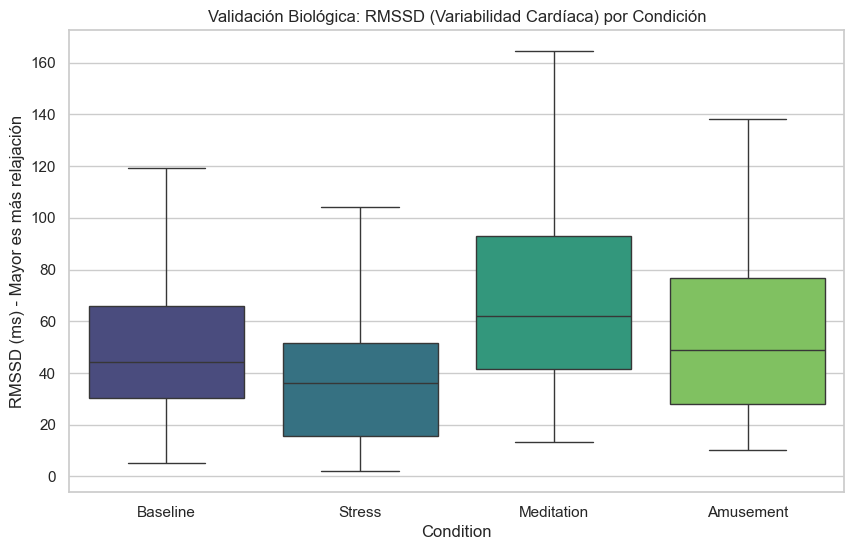

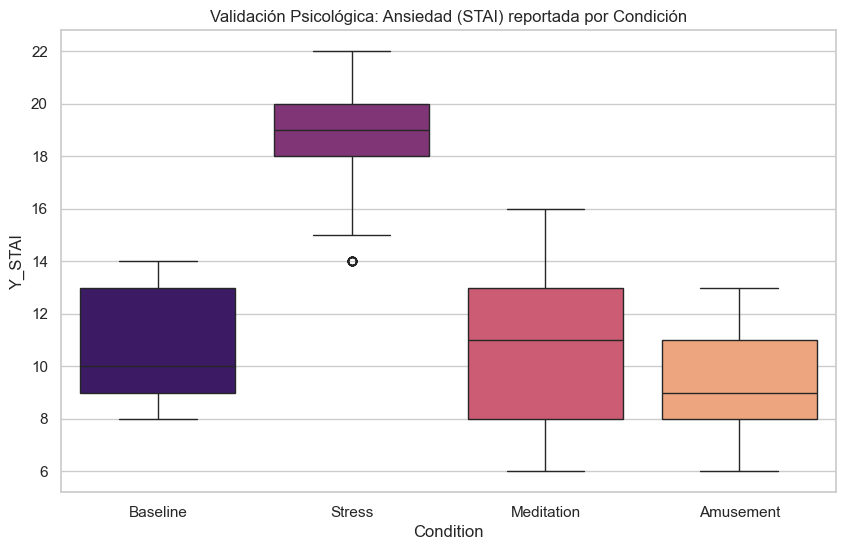

In [21]:
# --- AUDITORÍA DE CALIDAD DEL DATASET GENERADO ---
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargar el archivo final
df_final = pd.read_parquet(ml_path)

print("📊 REPORTE DE CALIDAD DEL DATASET")
print("="*40)
print(f"Dimensiones: {df_final.shape}")
print(f"Sujetos únicos: {df_final['Subject'].nunique()}")

# 2. Balance de Clases
print("\n⚖️ Distribución de Clases (Targets):")
print(df_final['Condition'].value_counts())

# 3. Chequeo de Nulos en Variables Críticas
# Verificamos si las métricas difíciles (Entropía) se calcularon
cols_check = ['ECG_HRV_RMSSD', 'ECG_HRV_SampEn', 'EDA_Tonic_Mean', 'Y_STAI']
print("\n🕵️ Conteo de Nulos en variables clave:")
print(df_final[cols_check].isnull().sum())

# 4. Visualización Rápida: Estrés vs Relax
# Si esto separa bien, tus modelos van a volar
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_final, x='Condition', y='ECG_HRV_RMSSD', palette='viridis', showfliers=False)
plt.title("Validación Biológica: RMSSD (Variabilidad Cardíaca) por Condición")
plt.ylabel("RMSSD (ms) - Mayor es más relajación")
plt.show()

# 5. Visualización de Targets Subjetivos
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_final, x='Condition', y='Y_STAI', palette='magma')
plt.title("Validación Psicológica: Ansiedad (STAI) reportada por Condición")
plt.show()

In [1]:
!jupyter nbconvert --to webpdf 02_Feature_Extraction_Advanced.ipynb

[NbConvertApp] Converting notebook 02_Feature_Extraction_Advanced.ipynb to webpdf
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Building PDF
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 1578223 bytes to 02_Feature_Extraction_Advanced.pdf


In [1]:
!jupyter nbconvert --to markdown 02_Feature_Extraction_Advanced.ipynb

[NbConvertApp] Converting notebook 02_Feature_Extraction_Advanced.ipynb to markdown
[NbConvertApp] Support files will be in 02_Feature_Extraction_Advanced_files\
[NbConvertApp] Making directory 02_Feature_Extraction_Advanced_files
[NbConvertApp] Writing 35344 bytes to 02_Feature_Extraction_Advanced.md
